
# Citi Bike - Availability Improvement Notebook Based on Follow-On v7

This notebook starts from the strongest conclusions in the **Follow-On Experiments v7** notebook and turns them into a more focused **availability improvement** workflow.

## Starting point from follow-on
- `utilization_ratio_next_hour` is the strongest next-hour availability-style target.
- **All v7 features** beat the reduced ablation sets.
- The follow-on run slightly favored **Top 50 busiest stations** over 150 and 300.
- Restricting to **capacity-known-only** rows did **not** meaningfully improve results.

## Goal here
Instead of asking *which framing is best?*, this notebook asks:
1. Can a **stronger model family** beat the original random-forest baseline?
2. Do **engineered availability-pressure features** help?
3. Does a **validation-weighted ensemble** help?
4. Does **state-conditioned routing** help, where low / mid / high current-utilization stations get different models?

The notebook is written to stay compatible with the same v7 parquet used in the follow-on notebook.


In [1]:

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped (not running in Colab or already mounted).')


Mounted at /content/drive


In [2]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

try:
    from xgboost import XGBRegressor
    HAVE_XGBOOST = True
except Exception:
    XGBRegressor = None
    HAVE_XGBOOST = False

print('xgboost available:', HAVE_XGBOOST)


xgboost available: True



## Configuration

Adjust these paths or knobs for your environment.

Notes:
- `FOLLOW_ON_DEFAULT_TOP_N = 50` matches the strongest result stored in the uploaded follow-on notebook.
- `MAX_ROWS_PER_EXPERIMENT` is set a bit lower than the follow-on notebook by default because this notebook trains **more models**.
- If you have `xgboost` installed, you can set `XGB_DEVICE = 'cuda'` on Colab with an A100.


In [3]:

FEATURE_CACHE_CANDIDATES = [
    Path('outputs/feature_df_model_ready_2025_v7_final.parquet'),
    Path('outputs/feature_df_model_ready_2025_v7.parquet'),
    Path('/content/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/content/feature_df_model_ready_2025_v7.parquet'),
    Path('/content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/content/drive/MyDrive/feature_df_model_ready_2025_v7.parquet'),
    Path('/mnt/data/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/mnt/data/feature_df_model_ready_2025_v7.parquet'),
    Path('/mnt/data/outputs/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/mnt/data/outputs/feature_df_model_ready_2025_v7.parquet'),
]

FOLLOW_ON_RESULTS_CANDIDATES = [
    Path('outputs'),
    Path('/content/outputs'),
    Path('/mnt/data/outputs'),
]

OUTPUT_DIR_CANDIDATES = [
    Path('outputs'),
    Path('/content/outputs'),
    Path('/mnt/data/outputs'),
]

PRIMARY_TARGET = 'utilization_ratio_next_hour'
FOLLOW_ON_DEFAULT_TOP_N = 50
RUN_HEAVY_EXPERIMENTS = True
SAVE_OUTPUT_TABLES = True
MAX_ROWS_PER_EXPERIMENT = 250_000
RANDOM_STATE = 42
INCLUDE_OPTIONAL_XGBOOST = True
XGB_DEVICE = 'cuda'   # change to 'cuda' on GPU Colab if xgboost is installed

print('Primary target:', PRIMARY_TARGET)
print('Follow-on default Top-N:', FOLLOW_ON_DEFAULT_TOP_N)
print('Heavy experiments enabled:', RUN_HEAVY_EXPERIMENTS)
print('Max rows per experiment:', MAX_ROWS_PER_EXPERIMENT)
print('XGBoost enabled:', INCLUDE_OPTIONAL_XGBOOST and HAVE_XGBOOST)
print('XGBoost device:', XGB_DEVICE)


Primary target: utilization_ratio_next_hour
Follow-on default Top-N: 50
Heavy experiments enabled: True
Max rows per experiment: 250000
XGBoost enabled: True
XGBoost device: cuda



## Optional: copy the v7 parquet from Drive into the runtime

Run this only if your runtime cannot see the parquet directly but Drive has the file.


In [4]:

# Example:
# import shutil
# src = '/content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet'
# dst = '/content/feature_df_model_ready_2025_v7_final.parquet'
# shutil.copy2(src, dst)
# print('Copied to:', dst)


## Load the v7 feature dataframe and infer the strongest follow-on setup

In [5]:

def locate_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


def resolve_output_dir(candidates):
    for path in candidates:
        try:
            path.mkdir(parents=True, exist_ok=True)
            return path
        except Exception:
            continue
    return None


def read_follow_on_csv(filename):
    for folder in FOLLOW_ON_RESULTS_CANDIDATES:
        path = folder / filename
        if path.exists():
            try:
                return pd.read_csv(path), path
            except Exception:
                pass
    return None, None


FEATURE_CACHE = locate_existing_path(FEATURE_CACHE_CANDIDATES)
OUTPUT_DIR = resolve_output_dir(OUTPUT_DIR_CANDIDATES)

print('Resolved feature cache:', FEATURE_CACHE)
print('Resolved output dir:', OUTPUT_DIR)

if FEATURE_CACHE is None:
    raise FileNotFoundError(
        'Could not find a v7 feature parquet. Update FEATURE_CACHE_CANDIDATES or copy the parquet into the runtime.'
    )

try:
    size = FEATURE_CACHE.stat().st_size
    with open(FEATURE_CACHE, 'rb') as f:
        head = f.read(4)
        f.seek(-4, 2)
        tail = f.read(4)
    print(f'Parquet integrity check -> size={size:,} head={head} tail={tail}')
except Exception as e:
    print('Parquet integrity check failed:', e)

feature_df = pd.read_parquet(FEATURE_CACHE)

if 'station_key' in feature_df.columns:
    feature_df['station_key'] = feature_df['station_key'].astype('category')
if 'station_cluster' in feature_df.columns:
    feature_df['station_cluster'] = feature_df['station_cluster'].astype('category')
if 'hour' in feature_df.columns:
    feature_df['hour'] = pd.to_datetime(feature_df['hour'])

follow_on_topn_df, follow_on_topn_path = read_follow_on_csv('topn_results.csv')
follow_on_ablation_df, follow_on_ablation_path = read_follow_on_csv('ablation_results.csv')

BEST_TOP_N = FOLLOW_ON_DEFAULT_TOP_N
FOLLOW_ON_FEATURE_WINNER = 'All v7 features'

if isinstance(follow_on_topn_df, pd.DataFrame) and not follow_on_topn_df.empty and 'r2' in follow_on_topn_df.columns:
    BEST_TOP_N = int(follow_on_topn_df.sort_values('r2', ascending=False).iloc[0]['top_n_stations'])
if isinstance(follow_on_ablation_df, pd.DataFrame) and not follow_on_ablation_df.empty and 'r2' in follow_on_ablation_df.columns:
    FOLLOW_ON_FEATURE_WINNER = str(follow_on_ablation_df.sort_values('r2', ascending=False).iloc[0]['experiment'])

print('Loaded shape:', feature_df.shape)
print('Follow-on top-N source:', follow_on_topn_path)
print('Follow-on ablation source:', follow_on_ablation_path)
print('Chosen Top-N for this notebook:', BEST_TOP_N)
print('Chosen feature-set starting point:', FOLLOW_ON_FEATURE_WINNER)
display(feature_df.head())


Resolved feature cache: /content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet
Resolved output dir: outputs
Parquet integrity check -> size=819,677,632 head=b'PAR1' tail=b'PAR1'
Loaded shape: (11966828, 97)
Follow-on top-N source: None
Follow-on ablation source: None
Chosen Top-N for this notebook: 50
Chosen feature-set starting point: All v7 features


,station_key,hour,departures,arrivals,net_flow,total_activity,station_id,station_name,lat,lng,station_name_norm,gbfs_name,capacity_raw,capacity_known,capacity_imputed,is_active_station,capacity,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,estimated_bikes,available_docks,utilization_ratio,is_nearly_empty,is_nearly_full,estimated_bikes_lag_1,estimated_bikes_lag_2,estimated_bikes_lag_24,estimated_bikes_roll_3,estimated_bikes_roll_24,available_docks_lag_1,available_docks_lag_2,available_docks_lag_24,available_docks_roll_3,available_docks_roll_24,utilization_ratio_lag_1,utilization_ratio_lag_2,utilization_ratio_lag_24,utilization_ratio_roll_3,utilization_ratio_roll_24,estimated_bikes_next_hour,available_docks_next_hour,utilization_ratio_next_hour,station_cluster,weather_pc_1,weather_pc_2,weather_pc_3
0,1234.56,2025-06-18 22:00:00,0,1,1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-5.000000e-01,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,13.0,11.0,0.541667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,11.0,0.541667,2,2.757381,-0.368786,-1.766357
1,1234.56,2025-06-18 23:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-2.588190e-01,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.000000,0.000000,1.0,NaN,NaN,1.000000,1.000000,1.0,NaN,NaN,1.000000,1.0,1.0,NaN,NaN,1.000000,1.000000,1.0,0.0,-1.0,13.0,11.0,0.541667,0,0,13.0,NaN,NaN,13.000000,13.000000,11.0,NaN,NaN,11.000000,11.000000,0.541667,NaN,NaN,0.541667,0.541667,11.0,13.0,0.458333,2,2.690833,-0.238696,-1.318855
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-2.588190e-01,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.500000,0.500000,1.0,1.0,NaN,1.000000,1.000000,0.0,1.0,NaN,0.500000,0.5,2.0,1.0,NaN,1.500000,1.500000,1.0,1.0,0.0,11.0,13.0,0.458333,0,0,13.0,13.0,NaN,13.000000,13.000000,11.0,11.0,NaN,11.000000,11.000000,0.541667,0.541667,NaN,0.541667,0.541667,12.0,12.0,0.500000,2,1.421356,0.119499,1.292002
3,1234.56,2025-06-20 09:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0,9,4,6,0,1,1,0,7.071068e-01,-0.707107,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,0.666667,0.666667,0.0,1.0,NaN,0.666667,0.666667,-1.0,0.0,NaN,0.000000,0.0,1.0,2.0,NaN,1.333333,1.333333,1.0,1.0,0.0,12.0,12.0,0.500000,0,0,11.0,13.0,NaN,12.333333,12.333333,13.0,11.0,NaN,11.666667,11.666667,0.458333,0.541667,NaN,0.513889,0.513889,12.0,12.0,0.500000,2,0.488080,-0.150773,2.193309
4,1234.56,2025-06-20 12:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0,

## Quick sanity checks

,column,non_null_rate,dtype
0,station_key,1.000000,category
1,hour,1.000000,datetime64[ns]
2,departures,1.000000,int32
3,arrivals,1.000000,int32
4,net_flow,1.000000,int32
5,total_activity,1.000000,int32
6,station_id,1.000000,string
7,station_name,1.000000,string
8,lat,1.000000,string
9,lng,1.000000,string


,count,mean,std,min,25%,50%,75%,max
capacity,11966828.0,35.013214,19.150441,0.0,21.000000,27.0,43.000000,123.0
capacity_known,11966828.0,0.988522,0.106519,0.0,1.000000,1.0,1.000000,1.0
capacity_imputed,11966828.0,0.011478,0.106519,0.0,0.000000,0.0,0.000000,1.0
estimated_bikes,11955321.0,17.058826,13.602242,0.0,9.000000,13.0,21.500000,123.0
available_docks,11955321.0,17.988117,12.835156,0.0,10.500000,14.5,22.500000,123.0
utilization_ratio,11955321.0,0.476879,0.218159,0.0,0.369565,0.5,0.586957,1.0
utilization_ratio_next_hour,11952895.0,0.476874,0.218179,0.0,0.369565,0.5,0.586957,1.0
is_nearly_empty,11966828.0,0.071982,0.258458,0.0,0.000000,0.0,0.000000,1.0
is_nearly_full,11966828.0,0.048334,0.214471,0.0,0.000000,0.0,0.000000,1.0
utilization_ratio_lag_1,11952895.0,0.476873,0.218168,0.0,0.369565,0.5,0.586957,1.0


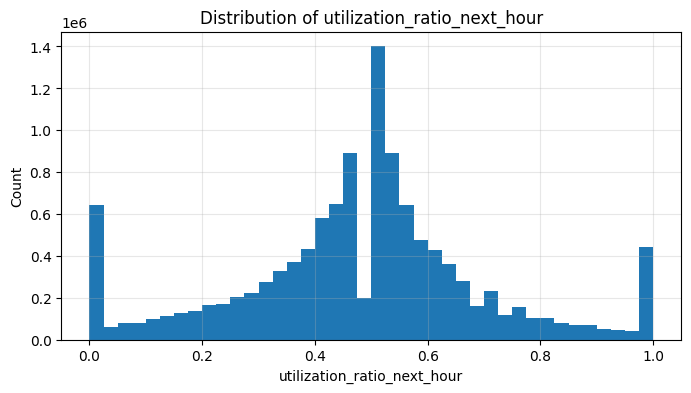

In [6]:

coverage = pd.DataFrame({
    'column': feature_df.columns,
    'non_null_rate': [feature_df[c].notna().mean() for c in feature_df.columns],
    'dtype': [str(feature_df[c].dtype) for c in feature_df.columns],
}).sort_values('non_null_rate', ascending=False)

display(coverage.head(50))

focus_cols = [
    c for c in [
        'capacity', 'capacity_known', 'capacity_imputed', 'estimated_bikes',
        'available_docks', 'utilization_ratio', 'utilization_ratio_next_hour',
        'is_nearly_empty', 'is_nearly_full', 'utilization_ratio_lag_1',
        'utilization_ratio_lag_24'
    ] if c in feature_df.columns
]

if focus_cols:
    display(feature_df[focus_cols].describe(include='all').T)

if PRIMARY_TARGET in feature_df.columns:
    plt.figure(figsize=(8, 4))
    feature_df[PRIMARY_TARGET].dropna().clip(0, 1).hist(bins=40)
    plt.title(f'Distribution of {PRIMARY_TARGET}')
    plt.xlabel(PRIMARY_TARGET)
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.show()



## Helpers and feature groups

This section keeps the same modeling assumptions as the follow-on notebook, then adds a few **engineered availability-pressure features**.

Important design choice:
- predictions are **clipped to [0, 1]** before scoring because the target is a utilization ratio.


In [7]:

def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float32)


FEATURE_GROUPS = {
    'calendar': [
        'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
        'is_rush_hour', 'is_commute_peak', 'is_overnight',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
    ],
    'weather': [
        'is_precipitating', 'is_raining', 'is_snowing', 'heavy_precip_flag'
    ],
    'raw_flow_state': [
        'departures_lag_1', 'departures_lag_2', 'departures_lag_24',
        'arrivals_lag_1', 'arrivals_lag_2', 'arrivals_lag_24',
        'net_flow_lag_1', 'net_flow_lag_2', 'net_flow_lag_24',
        'total_activity_lag_1', 'total_activity_lag_2', 'total_activity_lag_24',
        'departures_roll_3', 'departures_roll_24',
        'arrivals_roll_3', 'arrivals_roll_24',
        'net_flow_roll_3', 'net_flow_roll_24',
        'total_activity_roll_3', 'total_activity_roll_24',
    ],
    'availability_state': [
        'capacity', 'capacity_known', 'capacity_imputed', 'is_active_station',
        'estimated_bikes_lag_1', 'estimated_bikes_lag_2', 'estimated_bikes_lag_24',
        'estimated_bikes_roll_3', 'estimated_bikes_roll_24',
        'available_docks_lag_1', 'available_docks_lag_2', 'available_docks_lag_24',
        'available_docks_roll_3', 'available_docks_roll_24',
        'utilization_ratio_lag_1', 'utilization_ratio_lag_2', 'utilization_ratio_lag_24',
        'utilization_ratio_roll_3', 'utilization_ratio_roll_24',
        'is_nearly_empty', 'is_nearly_full',
    ],
    'spatial_station': ['station_key', 'station_cluster', 'lat', 'lng'],
}
FEATURE_GROUPS['weather_pca'] = []
FEATURE_GROUPS['engineered_edge'] = []


def add_weather_pca_features(df):
    return [c for c in df.columns if c.startswith('weather_pc_')]


def available_features(df, cols):
    return [c for c in cols if c in df.columns]


def safe_ratio(numerator, denominator):
    num = pd.to_numeric(numerator, errors='coerce')
    den = pd.to_numeric(denominator, errors='coerce')
    out = np.where((den > 0) & np.isfinite(den), num / den, np.nan)
    return pd.Series(out, index=numerator.index if hasattr(numerator, 'index') else None)


def add_engineered_availability_features(df):
    out = df.copy()
    engineered = []

    if {'utilization_ratio_lag_1', 'utilization_ratio_lag_2'}.issubset(out.columns):
        out['utilization_delta_1_2'] = pd.to_numeric(out['utilization_ratio_lag_1'], errors='coerce') - pd.to_numeric(out['utilization_ratio_lag_2'], errors='coerce')
        engineered.append('utilization_delta_1_2')

    if {'utilization_ratio_lag_1', 'utilization_ratio_lag_24'}.issubset(out.columns):
        out['utilization_delta_1_24'] = pd.to_numeric(out['utilization_ratio_lag_1'], errors='coerce') - pd.to_numeric(out['utilization_ratio_lag_24'], errors='coerce')
        engineered.append('utilization_delta_1_24')

    if {'estimated_bikes_lag_1', 'capacity'}.issubset(out.columns):
        out['estimated_bikes_capacity_ratio_lag_1'] = safe_ratio(out['estimated_bikes_lag_1'], out['capacity'])
        engineered.append('estimated_bikes_capacity_ratio_lag_1')

    if {'available_docks_lag_1', 'capacity'}.issubset(out.columns):
        out['available_docks_capacity_ratio_lag_1'] = safe_ratio(out['available_docks_lag_1'], out['capacity'])
        engineered.append('available_docks_capacity_ratio_lag_1')

    if {'total_activity_roll_3', 'capacity'}.issubset(out.columns):
        out['activity_pressure_roll_3'] = safe_ratio(out['total_activity_roll_3'], out['capacity'])
        engineered.append('activity_pressure_roll_3')

    if {'total_activity_roll_24', 'capacity'}.issubset(out.columns):
        out['activity_pressure_roll_24'] = safe_ratio(out['total_activity_roll_24'], out['capacity'])
        engineered.append('activity_pressure_roll_24')

    if {'is_commute_peak', 'is_precipitating'}.issubset(out.columns):
        out['commute_precip_interaction'] = pd.to_numeric(out['is_commute_peak'], errors='coerce').fillna(0) * pd.to_numeric(out['is_precipitating'], errors='coerce').fillna(0)
        engineered.append('commute_precip_interaction')

    if {'is_weekend', 'is_precipitating'}.issubset(out.columns):
        out['weekend_precip_interaction'] = pd.to_numeric(out['is_weekend'], errors='coerce').fillna(0) * pd.to_numeric(out['is_precipitating'], errors='coerce').fillna(0)
        engineered.append('weekend_precip_interaction')

    if {'is_nearly_empty', 'is_commute_peak'}.issubset(out.columns):
        out['empty_peak_interaction'] = pd.to_numeric(out['is_nearly_empty'], errors='coerce').fillna(0) * pd.to_numeric(out['is_commute_peak'], errors='coerce').fillna(0)
        engineered.append('empty_peak_interaction')

    if {'is_nearly_full', 'is_commute_peak'}.issubset(out.columns):
        out['full_peak_interaction'] = pd.to_numeric(out['is_nearly_full'], errors='coerce').fillna(0) * pd.to_numeric(out['is_commute_peak'], errors='coerce').fillna(0)
        engineered.append('full_peak_interaction')

    return out, engineered


feature_df_plus, engineered_cols = add_engineered_availability_features(feature_df)
FEATURE_GROUPS['weather_pca'] = add_weather_pca_features(feature_df_plus)
FEATURE_GROUPS['engineered_edge'] = engineered_cols


def busiest_station_keys(df, top_n=50):
    activity_col = 'total_activity' if 'total_activity' in df.columns else 'departures'
    return (
        df.groupby('station_key', observed=True)[activity_col]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )


def chronological_split(model_df):
    model_df = model_df.sort_values('hour').reset_index(drop=True)
    unique_hours = np.sort(model_df['hour'].dropna().unique())
    if len(unique_hours) < 10:
        raise ValueError('Not enough hourly periods for a 70/15/15 chronological split.')

    train_idx = max(1, int(len(unique_hours) * 0.70))
    valid_idx = max(train_idx + 1, int(len(unique_hours) * 0.85))
    valid_idx = min(valid_idx, len(unique_hours) - 1)

    train_cutoff = unique_hours[train_idx]
    valid_cutoff = unique_hours[valid_idx]

    train_df = model_df.loc[model_df['hour'] < train_cutoff].copy()
    valid_df = model_df.loc[(model_df['hour'] >= train_cutoff) & (model_df['hour'] < valid_cutoff)].copy()
    test_df = model_df.loc[model_df['hour'] >= valid_cutoff].copy()
    return train_df, valid_df, test_df


class DenseTabularPreprocessor:
    def __init__(self, numeric_features, categorical_features):
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.num_imputer = SimpleImputer(strategy='median') if self.numeric_features else None
        self.cat_imputer = SimpleImputer(strategy='most_frequent') if self.categorical_features else None
        self.onehot = make_dense_onehot_encoder() if self.categorical_features else None
        self.feature_names_out_ = None

    def fit(self, X):
        feature_names = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors='coerce')
            self.num_imputer.fit(num_df)
            feature_names.extend(self.numeric_features)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype('string')
            cat_filled = self.cat_imputer.fit_transform(cat_df)
            self.onehot.fit(cat_filled)
            feature_names.extend(self.onehot.get_feature_names_out(self.categorical_features).tolist())

        self.feature_names_out_ = np.asarray(feature_names, dtype=object)
        return self

    def transform(self, X):
        parts = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors='coerce')
            num_arr = self.num_imputer.transform(num_df).astype(np.float32, copy=False)
            parts.append(num_arr)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype('string')
            cat_filled = self.cat_imputer.transform(cat_df)
            cat_arr = self.onehot.transform(cat_filled).astype(np.float32, copy=False)
            parts.append(cat_arr)

        if not parts:
            return np.empty((len(X), 0), dtype=np.float32)
        return np.concatenate(parts, axis=1).astype(np.float32, copy=False)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def prepare_xy(train_df, valid_df, test_df, feature_cols, target_col):
    categorical = [
        c for c in feature_cols
        if str(train_df[c].dtype) in {'category', 'string'} or c in {'station_key', 'station_cluster'}
    ]
    categorical = [c for c in categorical if c in feature_cols]
    numeric = [c for c in feature_cols if c not in categorical]

    prep = DenseTabularPreprocessor(numeric_features=numeric, categorical_features=categorical)
    X_train = prep.fit_transform(train_df[feature_cols])
    X_valid = prep.transform(valid_df[feature_cols])
    X_test = prep.transform(test_df[feature_cols])

    y_train = pd.to_numeric(train_df[target_col], errors='coerce').to_numpy()
    y_valid = pd.to_numeric(valid_df[target_col], errors='coerce').to_numpy()
    y_test = pd.to_numeric(test_df[target_col], errors='coerce').to_numpy()
    return prep, X_train, X_valid, X_test, y_train, y_valid, y_test


def maybe_downsample(df, max_rows=MAX_ROWS_PER_EXPERIMENT):
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    return df.sample(max_rows, random_state=RANDOM_STATE).sort_values('hour').reset_index(drop=True)


def build_model_df(df, target_col, feature_cols, top_n=50, require_capacity_known=False):
    busy = busiest_station_keys(df, top_n=top_n)
    keep_cols = ['hour', target_col] + [c for c in feature_cols if c in df.columns]

    base_mask = df['station_key'].isin(busy)
    if require_capacity_known and 'capacity_known' in df.columns:
        base_mask = base_mask & (pd.to_numeric(df['capacity_known'], errors='coerce') == 1)

    model_df = df.loc[base_mask, keep_cols].copy()
    model_df = model_df.loc[model_df[target_col].notna()].copy()

    for col in ['station_key', 'station_cluster']:
        if col in model_df.columns:
            model_df[col] = model_df[col].astype('category')

    return maybe_downsample(model_df)


def clip_ratio_predictions(pred):
    return np.clip(np.asarray(pred, dtype=float), 0.0, 1.0)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_ratio_predictions(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    abs_err = np.abs(y_true - y_pred)
    return {
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
        'within_0.05': float(np.mean(abs_err <= 0.05)),
        'within_0.10': float(np.mean(abs_err <= 0.10)),
    }


def get_model_factories():
    factories = {
        'Naive mean': None,
        'Linear Regression': lambda: LinearRegression(),
        'Ridge': lambda: Ridge(alpha=1.0),
        'Random Forest': lambda: RandomForestRegressor(
            n_estimators=140,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'Random Forest (deeper)': lambda: RandomForestRegressor(
            n_estimators=240,
            max_depth=18,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'Extra Trees': lambda: ExtraTreesRegressor(
            n_estimators=320,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'HistGradientBoosting': lambda: HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=260,
            min_samples_leaf=30,
            l2_regularization=0.0,
            random_state=RANDOM_STATE,
        ),
    }

    if INCLUDE_OPTIONAL_XGBOOST and HAVE_XGBOOST:
        factories['XGBoost'] = lambda: XGBRegressor(
            objective='reg:squarederror',
            n_estimators=360,
            learning_rate=0.05,
            max_depth=8,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            tree_method='hist',
            device=XGB_DEVICE,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    return factories


def fit_regression_suite(train_df, valid_df, test_df, feature_cols, target_col, model_names=None):
    prep, X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_xy(
        train_df, valid_df, test_df, feature_cols, target_col
    )

    factories = get_model_factories()
    if model_names is not None:
        factories = {k: v for k, v in factories.items() if k in model_names}

    baseline_value = float(np.nanmean(y_train))
    valid_baseline = np.repeat(baseline_value, len(y_valid))
    test_baseline = np.repeat(baseline_value, len(y_test))

    rows = []
    artifacts = {}

    rows.append({'model': 'Naive mean', 'split': 'validation', **regression_metrics(y_valid, valid_baseline)})
    rows.append({'model': 'Naive mean', 'split': 'test', **regression_metrics(y_test, test_baseline)})
    artifacts['Naive mean'] = {
        'model': None,
        'feature_names': prep.feature_names_out_,
        'valid_pred': clip_ratio_predictions(valid_baseline),
        'test_pred': clip_ratio_predictions(test_baseline),
        'y_valid': y_valid,
        'y_test': y_test,
        'test_df': test_df.copy(),
    }

    for name, make_model in factories.items():
        if name == 'Naive mean' or make_model is None:
            continue
        model = make_model()
        model.fit(X_train, y_train)
        valid_pred = clip_ratio_predictions(model.predict(X_valid))
        test_pred = clip_ratio_predictions(model.predict(X_test))

        rows.append({'model': name, 'split': 'validation', **regression_metrics(y_valid, valid_pred)})
        rows.append({'model': name, 'split': 'test', **regression_metrics(y_test, test_pred)})
        artifacts[name] = {
            'model': model,
            'preprocessor': prep,
            'feature_names': prep.feature_names_out_,
            'valid_pred': valid_pred,
            'test_pred': test_pred,
            'y_valid': y_valid,
            'y_test': y_test,
            'test_df': test_df.copy(),
        }

    metrics_df = pd.DataFrame(rows)
    return metrics_df, artifacts


def pick_best_model(metrics_df, split='validation', metric='r2'):
    frame = metrics_df.loc[metrics_df['split'] == split].sort_values(metric, ascending=False)
    return frame.iloc[0]['model'] if not frame.empty else None


def top_feature_importance(trained_artifacts, model_name, top_k=20):
    artifact = trained_artifacts.get(model_name)
    if artifact is None:
        return None
    model = artifact.get('model')
    if model is None or not hasattr(model, 'feature_importances_'):
        return None
    out = pd.DataFrame({
        'feature': artifact['feature_names'],
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
    return out.head(top_k)


def summarize_best_test_row(metrics_df, selection_metric='r2'):
    best_model = pick_best_model(metrics_df, split='validation', metric=selection_metric)
    test_row = metrics_df.loc[(metrics_df['split'] == 'test') & (metrics_df['model'] == best_model)].iloc[0].to_dict()
    test_row['selected_model'] = best_model
    return test_row


def validation_weighted_ensemble(metrics_df, artifacts, top_k=3):
    valid_rows = metrics_df.loc[metrics_df['split'] == 'validation'].copy()
    valid_rows = valid_rows.loc[valid_rows['model'] != 'Naive mean'].sort_values('r2', ascending=False).head(top_k)
    if valid_rows.empty:
        raise ValueError('No eligible models for ensembling.')

    weights = np.maximum(valid_rows['r2'].to_numpy(dtype=float), 0.0)
    if np.allclose(weights.sum(), 0):
        weights = np.ones_like(weights)
    weights = weights / weights.sum()

    model_names = valid_rows['model'].tolist()
    valid_pred = np.zeros_like(next(iter(artifacts.values()))['y_valid'], dtype=float)
    test_pred = np.zeros_like(next(iter(artifacts.values()))['y_test'], dtype=float)

    for weight, model_name in zip(weights, model_names):
        valid_pred += weight * artifacts[model_name]['valid_pred']
        test_pred += weight * artifacts[model_name]['test_pred']

    y_valid = next(iter(artifacts.values()))['y_valid']
    y_test = next(iter(artifacts.values()))['y_test']

    out = pd.DataFrame([
        {'split': 'validation', **regression_metrics(y_valid, valid_pred)},
        {'split': 'test', **regression_metrics(y_test, test_pred)},
    ])
    return out, pd.DataFrame({'model': model_names, 'weight': weights})


def add_regime_column(df, source_col='utilization_ratio_lag_1'):
    out = df.copy()
    vals = pd.to_numeric(out[source_col], errors='coerce')
    regime = np.where(vals <= 0.20, 'low', np.where(vals >= 0.80, 'high', 'mid'))
    out['routing_regime'] = pd.Series(regime, index=out.index).astype('category')
    out.loc[vals.isna(), 'routing_regime'] = np.nan
    return out


def fit_regime_routing(train_df, valid_df, test_df, feature_cols, target_col, model_name):
    base_metrics, base_artifacts = fit_regression_suite(
        train_df, valid_df, test_df, feature_cols, target_col, model_names=[model_name]
    )
    global_valid = base_artifacts[model_name]['valid_pred']
    global_test = base_artifacts[model_name]['test_pred']
    y_valid = base_artifacts[model_name]['y_valid']
    y_test = base_artifacts[model_name]['y_test']

    routed_valid = global_valid.copy()
    routed_test = global_test.copy()

    train_aug = add_regime_column(train_df)
    valid_aug = add_regime_column(valid_df)
    test_aug = add_regime_column(test_df)

    regime_details = []
    for regime in ['low', 'mid', 'high']:
        tr = train_aug.loc[train_aug['routing_regime'] == regime].copy()
        va = valid_aug.loc[valid_aug['routing_regime'] == regime].copy()
        te = test_aug.loc[test_aug['routing_regime'] == regime].copy()

        enough_rows = len(tr) >= 300 and len(va) >= 100 and len(te) >= 100
        regime_details.append({
            'regime': regime,
            'train_rows': len(tr),
            'valid_rows': len(va),
            'test_rows': len(te),
            'used_specialized_model': bool(enough_rows),
        })

        if not enough_rows:
            continue

        reg_metrics, reg_artifacts = fit_regression_suite(
            tr, va, te, feature_cols, target_col, model_names=[model_name]
        )
        routed_valid[valid_aug['routing_regime'] == regime] = reg_artifacts[model_name]['valid_pred']
        routed_test[test_aug['routing_regime'] == regime] = reg_artifacts[model_name]['test_pred']

    comparison = pd.DataFrame([
        {'approach': 'Global model', 'split': 'validation', **regression_metrics(y_valid, global_valid)},
        {'approach': 'Global model', 'split': 'test', **regression_metrics(y_test, global_test)},
        {'approach': 'Regime-routed model', 'split': 'validation', **regression_metrics(y_valid, routed_valid)},
        {'approach': 'Regime-routed model', 'split': 'test', **regression_metrics(y_test, routed_test)},
    ])

    routed_artifact = {
        'valid_pred': routed_valid,
        'test_pred': routed_test,
        'y_valid': y_valid,
        'y_test': y_test,
        'test_df': test_aug.copy(),
        'details': pd.DataFrame(regime_details),
    }
    return comparison, routed_artifact


def regime_slice_metrics(test_df, y_true, y_pred, source_col='utilization_ratio_lag_1'):
    eval_df = test_df.copy().reset_index(drop=True)
    eval_df['y_true'] = np.asarray(y_true, dtype=float)
    eval_df['y_pred'] = clip_ratio_predictions(y_pred)
    eval_df = add_regime_column(eval_df, source_col=source_col)

    rows = []
    for regime, group in eval_df.groupby('routing_regime', observed=True):
        if group.empty:
            continue
        rows.append({
            'regime': regime,
            'rows': len(group),
            **regression_metrics(group['y_true'], group['y_pred'])
        })
    return pd.DataFrame(rows).sort_values('regime')


CORE_ALL = list(dict.fromkeys(
    FEATURE_GROUPS['calendar']
    + FEATURE_GROUPS['weather']
    + FEATURE_GROUPS['weather_pca']
    + FEATURE_GROUPS['raw_flow_state']
    + FEATURE_GROUPS['availability_state']
    + FEATURE_GROUPS['spatial_station']
))

ALL_V7_FEATURES = available_features(feature_df_plus, CORE_ALL)
ALL_V7_PLUS_ENGINEERED = available_features(feature_df_plus, CORE_ALL + FEATURE_GROUPS['engineered_edge'])
COMPACT_AVAILABILITY = available_features(
    feature_df_plus,
    FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['weather'] + FEATURE_GROUPS['availability_state'] + FEATURE_GROUPS['spatial_station']
)
COMPACT_AVAILABILITY_PLUS_ENGINEERED = available_features(
    feature_df_plus,
    FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['weather'] + FEATURE_GROUPS['availability_state'] + FEATURE_GROUPS['spatial_station'] + FEATURE_GROUPS['engineered_edge']
)

FEATURE_SET_CANDIDATES = {
    'All v7 features': ALL_V7_FEATURES,
    'All v7 + engineered': ALL_V7_PLUS_ENGINEERED,
    'Compact availability': COMPACT_AVAILABILITY,
    'Compact availability + engineered': COMPACT_AVAILABILITY_PLUS_ENGINEERED,
}

print('Engineered features:', FEATURE_GROUPS['engineered_edge'])
for name, cols in FEATURE_SET_CANDIDATES.items():
    print(f'{name:34} -> {len(cols)} features')


Engineered features: ['utilization_delta_1_2', 'utilization_delta_1_24', 'estimated_bikes_capacity_ratio_lag_1', 'available_docks_capacity_ratio_lag_1', 'activity_pressure_roll_3', 'activity_pressure_roll_24', 'commute_precip_interaction', 'weekend_precip_interaction', 'empty_peak_interaction', 'full_peak_interaction']
All v7 features                    -> 64 features
All v7 + engineered                -> 74 features
Compact availability               -> 41 features
Compact availability + engineered  -> 51 features



## Experiment 1 - rebuild the strongest follow-on baseline

This uses the strongest setting carried over from follow-on:
- target = `utilization_ratio_next_hour`
- feature set = **All v7 features**
- station subset = **Top-N from follow-on** (default 50 if no saved CSV is available)


In [8]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    baseline_feature_set_name = 'All v7 features'
    baseline_feature_cols = FEATURE_SET_CANDIDATES[baseline_feature_set_name]

    baseline_model_df = build_model_df(
        feature_df_plus,
        PRIMARY_TARGET,
        baseline_feature_cols,
        top_n=BEST_TOP_N,
        require_capacity_known=False,
    )
    baseline_train_df, baseline_valid_df, baseline_test_df = chronological_split(baseline_model_df)

    baseline_metrics, baseline_artifacts = fit_regression_suite(
        baseline_train_df,
        baseline_valid_df,
        baseline_test_df,
        baseline_feature_cols,
        PRIMARY_TARGET,
        model_names=['Naive mean', 'Linear Regression', 'Ridge', 'Random Forest', 'Random Forest (deeper)'],
    )

    display(Markdown(f'### Baseline rebuild using Top {BEST_TOP_N} stations'))
    display(baseline_metrics.sort_values(['split', 'r2'], ascending=[True, False]))

    baseline_best = summarize_best_test_row(baseline_metrics)
    display(pd.DataFrame([baseline_best]))


### Baseline rebuild using Top 50 stations

,model,split,rmse,mae,r2,within_0.05,within_0.10
7,Random Forest,test,0.099268,0.068056,0.839192,0.532521,0.774027
9,Random Forest (deeper),test,0.099986,0.067883,0.836860,0.539260,0.774849
5,Ridge,test,0.126807,0.090361,0.737595,0.410301,0.672055
3,Linear Regression,test,0.145149,0.105664,0.656192,0.368575,0.604192
1,Naive mean,test,0.247766,0.185930,-0.001773,0.237644,0.431616
6,Random Forest,validation,0.113677,0.076738,0.837947,0.506981,0.730099
8,Random Forest (deeper),validation,0.114712,0.076972,0.834984,0.510300,0.730283
4,Ridge,validation,0.144738,0.102650,0.737291,0.378826,0.626363
2,Linear Regression,validation,0.167713,0.125096,0.647270,0.311311,0.525315
0,Naive mean,validation,0.282852,0.220185,-0.003293,0.214715,0.372030


,model,split,rmse,mae,r2,within_0.05,within_0.10,selected_model
0,Random Forest,test,0.099268,0.068056,0.839192,0.532521,0.774027,Random Forest



## Experiment 2 - stronger model family sweep

This is the main improvement attempt.

The notebook compares the original random-forest-style baseline against:
- `ExtraTreesRegressor`
- `HistGradientBoostingRegressor`
- optional `XGBoost` if installed


,model,split,rmse,mae,r2,within_0.05,within_0.10
0,Extra Trees,test,0.094560,0.064971,0.854085,0.550027,0.786877
1,XGBoost,test,0.094962,0.065259,0.852842,0.544247,0.785616
2,Random Forest,test,0.099268,0.068056,0.839192,0.532521,0.774027
3,Random Forest (deeper),test,0.099986,0.067883,0.836860,0.539260,0.774849
4,HistGradientBoosting,test,0.100029,0.068667,0.836718,0.531397,0.771836
5,Ridge,test,0.126807,0.090361,0.737595,0.410301,0.672055
6,Linear Regression,test,0.145149,0.105664,0.656192,0.368575,0.604192
7,Naive mean,test,0.247766,0.185930,-0.001773,0.237644,0.431616
8,Extra Trees,validation,0.106465,0.071557,0.857857,0.533007,0.750171
9,XGBoost,validation,0.107495,0.072761,0.855093,0.523444,0.742690


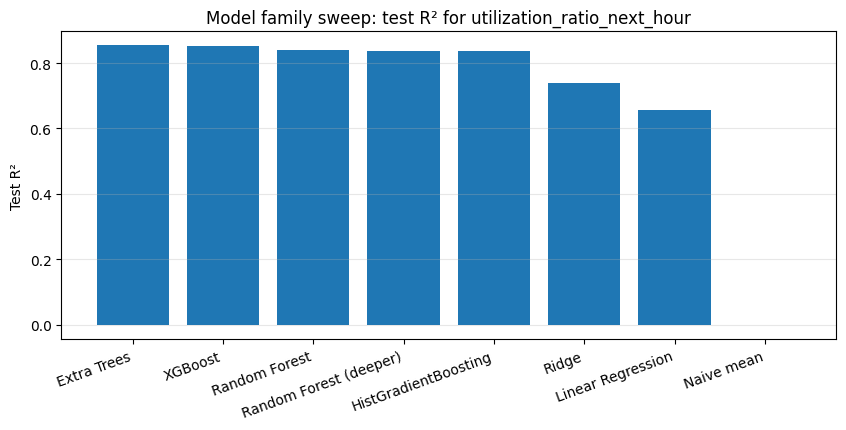

Best validation model family: Extra Trees


In [8]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    model_sweep_feature_cols = FEATURE_SET_CANDIDATES['All v7 features']
    model_sweep_df = build_model_df(feature_df_plus, PRIMARY_TARGET, model_sweep_feature_cols, top_n=BEST_TOP_N)
    model_sweep_train_df, model_sweep_valid_df, model_sweep_test_df = chronological_split(model_sweep_df)

    model_sweep_metrics, model_sweep_artifacts = fit_regression_suite(
        model_sweep_train_df,
        model_sweep_valid_df,
        model_sweep_test_df,
        model_sweep_feature_cols,
        PRIMARY_TARGET,
    )

    model_sweep_results = model_sweep_metrics.sort_values(['split', 'r2'], ascending=[True, False]).reset_index(drop=True)
    display(model_sweep_results)

    plot_df = model_sweep_results.loc[model_sweep_results['split'] == 'test'].sort_values('r2', ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(plot_df['model'], plot_df['r2'])
    plt.title('Model family sweep: test R² for utilization_ratio_next_hour')
    plt.ylabel('Test R²')
    plt.xticks(rotation=20, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

    best_model_family = pick_best_model(model_sweep_metrics, split='validation', metric='r2')
    print('Best validation model family:', best_model_family)



## Experiment 3 - feature engineering sweep

Now keep the **best model family** fixed and check whether the engineered availability-pressure features help.


,model,split,rmse,mae,r2,within_0.05,within_0.10,selected_model,feature_set,feature_count,rows_used
0,Extra Trees,test,0.094560,0.064971,0.854085,0.550027,0.786877,Extra Trees,All v7 features,64,250000
1,Extra Trees,test,0.095366,0.065391,0.851588,0.546493,0.785041,Extra Trees,All v7 + engineered,74,250000
3,Extra Trees,test,0.098680,0.067950,0.841093,0.529726,0.772575,Extra Trees,Compact availability + engineered,51,250000
2,Extra Trees,test,0.101663,0.070247,0.831341,0.517644,0.760274,Extra Trees,Compact availability,41,250000


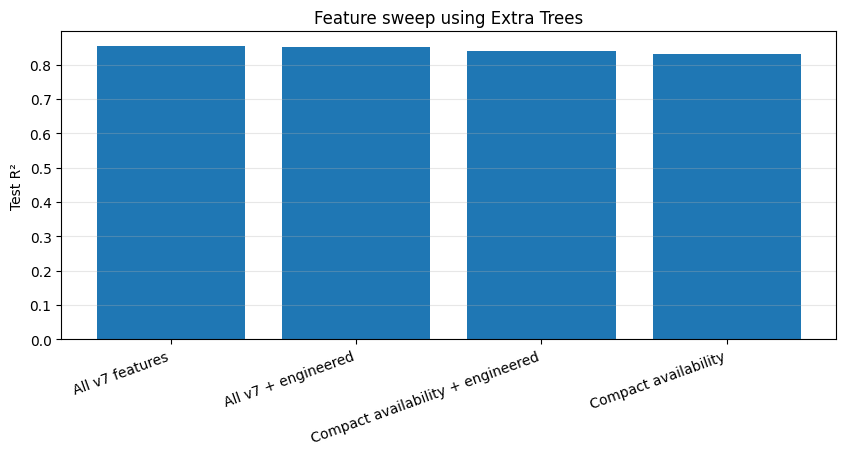

Best feature set: All v7 features


In [9]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    feature_sweep_rows = []
    feature_sweep_artifacts = {}

    for label, cols in FEATURE_SET_CANDIDATES.items():
        model_df = build_model_df(feature_df_plus, PRIMARY_TARGET, cols, top_n=BEST_TOP_N)
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(
            train_df,
            valid_df,
            test_df,
            cols,
            PRIMARY_TARGET,
            model_names=['Naive mean', best_model_family],
        )

        best_row = summarize_best_test_row(metrics_df)
        best_row['feature_set'] = label
        best_row['feature_count'] = len(cols)
        best_row['rows_used'] = len(model_df)
        feature_sweep_rows.append(best_row)
        feature_sweep_artifacts[label] = {'metrics_df': metrics_df, 'artifacts': artifacts, 'feature_cols': cols}

    feature_sweep_results = pd.DataFrame(feature_sweep_rows).sort_values('r2', ascending=False)
    display(feature_sweep_results)

    plt.figure(figsize=(10, 4))
    plt.bar(feature_sweep_results['feature_set'], feature_sweep_results['r2'])
    plt.title(f'Feature sweep using {best_model_family}')
    plt.ylabel('Test R²')
    plt.xticks(rotation=20, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

    best_feature_set_name = feature_sweep_results.iloc[0]['feature_set']
    best_feature_cols = feature_sweep_artifacts[best_feature_set_name]['feature_cols']
    print('Best feature set:', best_feature_set_name)



## Experiment 4 - validation-weighted ensemble

This combines the top validation models from the **base All-v7 feature set**.


In [10]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    ensemble_metrics, ensemble_weights = validation_weighted_ensemble(model_sweep_metrics, model_sweep_artifacts, top_k=3)
    display(ensemble_weights)
    display(ensemble_metrics)


,model,weight
0,Extra Trees,0.336296
1,XGBoost,0.335213
2,Random Forest,0.328491


,split,rmse,mae,r2,within_0.05,within_0.10
0,validation,0.107488,0.072564,0.855112,0.528081,0.747063
1,test,0.094517,0.064907,0.854218,0.551096,0.787699



## Experiment 5 - state-conditioned routing

This tries a practical operational idea:
- stations that are currently **low utilization** may behave differently than stations that are **mid** or **high utilization**,
- so route them to different models based on `utilization_ratio_lag_1`.

The routing threshold is based only on **current known state**, so it is leakage-safe.


In [11]:
# Memory cleanup cell: run this RIGHT BEFORE Experiment 5
import gc

print("Starting memory cleanup...")

# Keep only the small objects that later experiments are likely to need
_keep = {}

for name in [
    "best_model_family",
    "best_feature_set_name",
    "best_feature_cols",
    "BEST_TOP_N",
    "ensemble_metrics",
    "model_sweep_metrics",
    "feature_sweep_results",
]:
    if name in globals():
        _keep[name] = globals()[name]

# Keep only the single best artifact instead of every trained model/artifact
if "model_sweep_artifacts" in globals():
    try:
        if "best_model_family" in globals() and best_model_family in model_sweep_artifacts:
            _keep["model_sweep_artifacts"] = {
                best_model_family: model_sweep_artifacts[best_model_family]
            }
        else:
            print("Could not reduce model_sweep_artifacts automatically; dropping it entirely.")
    except Exception as e:
        print(f"Warning while trimming model_sweep_artifacts: {e}")

# Names that are commonly large and safe to remove before Experiment 5
delete_candidates = [
    # original / duplicate full dataframes
    "feature_df",
    "baseline_model_df",
    "baseline_train_df",
    "baseline_valid_df",
    "baseline_test_df",
    "model_sweep_df",
    "model_sweep_train_df",
    "model_sweep_valid_df",
    "model_sweep_test_df",
    "feature_sweep_df",
    "feature_sweep_train_df",
    "feature_sweep_valid_df",
    "feature_sweep_test_df",

    # large artifact dicts from earlier experiments
    "baseline_artifacts",
    "feature_sweep_artifacts",

    # result tables no longer needed for routing / later experiments
    "baseline_metrics",
    "baseline_results",
    "model_sweep_results",

    # large temporary matrices / arrays if they exist
    "X_train",
    "X_valid",
    "X_test",
    "y_train",
    "y_valid",
    "y_test",
]

deleted = []
for name in delete_candidates:
    if name in globals():
        try:
            del globals()[name]
            deleted.append(name)
        except Exception as e:
            print(f"Could not delete {name}: {e}")

# Restore the small objects we intentionally kept
globals().update(_keep)

collected = gc.collect()

print(f"Deleted {len(deleted)} objects.")
print(f"Garbage collector reclaimed {collected} objects.")
print("Cleanup finished.")

# Optional: quick RAM check if psutil is available
try:
    import psutil, os
    process = psutil.Process(os.getpid())
    mem_gb = process.memory_info().rss / (1024 ** 3)
    print(f"Current process memory: {mem_gb:.2f} GB")
except Exception:
    pass

Starting memory cleanup...
Deleted 7 objects.
Garbage collector reclaimed 8357 objects.
Cleanup finished.
Current process memory: 36.97 GB


In [12]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    routed_model_df = build_model_df(feature_df_plus, PRIMARY_TARGET, best_feature_cols, top_n=BEST_TOP_N)
    routed_train_df, routed_valid_df, routed_test_df = chronological_split(routed_model_df)

    routing_results, routing_artifact = fit_regime_routing(
        routed_train_df,
        routed_valid_df,
        routed_test_df,
        best_feature_cols,
        PRIMARY_TARGET,
        model_name=best_model_family,
    )

    display(routing_results)
    display(routing_artifact['details'])


,approach,split,rmse,mae,r2,within_0.05,within_0.10
0,Global model,validation,0.106465,0.071557,0.857857,0.533007,0.750171
1,Global model,test,0.094560,0.064971,0.854085,0.550027,0.786877
2,Regime-routed model,validation,0.107089,0.071959,0.856185,0.531005,0.747484
3,Regime-routed model,test,0.095351,0.065316,0.851633,0.547644,0.784740


,regime,train_rows,valid_rows,test_rows,used_specialized_model
0,low,18840,4554,3697,True
1,mid,126309,25046,27564,True
2,high,30358,8362,5239,True



## Experiment 6 - regime-by-regime error analysis for the strongest candidates

This helps you answer a report question like:

> Are errors concentrated at nearly-empty / nearly-full stations, or are they spread evenly?


In [16]:
print("Starting post-Experiment-5 cleanup...")

# 1) Delete large routed DataFrames created in Experiment 5
for name in [
    "routed_model_df",
    "routed_train_df",
    "routed_valid_df",
    "routed_test_df",
]:
    if name in globals():
        del globals()[name]

# 2) Shrink routing_artifact to only what Experiment 6 actually needs
if "routing_artifact" in globals():
    routing_artifact = {
        "test_df": routing_artifact["test_df"],
        "y_test": routing_artifact["y_test"],
        "test_pred": routing_artifact["test_pred"],
    }

# 3) Shrink model_sweep_artifacts to only the best global model
if "model_sweep_metrics" in globals() and "model_sweep_artifacts" in globals():
    try:
        base_best_model = pick_best_model(model_sweep_metrics, split="validation", metric="r2")
        if base_best_model in model_sweep_artifacts:
            model_sweep_artifacts = {
                base_best_model: model_sweep_artifacts[base_best_model]
            }
            print(f"Kept only best global artifact: {base_best_model}")
    except Exception as e:
        print(f"Could not trim model_sweep_artifacts: {e}")

# 4) ensemble_weights is not used by Experiment 6
if "ensemble_weights" in globals():
    del ensemble_weights

collected = gc.collect()
print(f"Garbage collector reclaimed {collected} objects.")

try:
    import psutil, os
    process = psutil.Process(os.getpid())
    mem_gb = process.memory_info().rss / (1024 ** 3)
    print(f"Current process memory: {mem_gb:.2f} GB")
except Exception:
    pass

Starting post-Experiment-5 cleanup...
Kept only best global artifact: Extra Trees
Garbage collector reclaimed 5222 objects.
Current process memory: 37.02 GB


In [13]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    candidate_rows = []

    base_best_model = pick_best_model(model_sweep_metrics, split='validation', metric='r2')
    base_best_test = model_sweep_metrics.loc[
        (model_sweep_metrics['split'] == 'test') & (model_sweep_metrics['model'] == base_best_model)
    ].iloc[0].to_dict()
    base_best_test['candidate'] = f'Global {base_best_model} / All v7'
    candidate_rows.append(base_best_test)

    ensemble_test = ensemble_metrics.loc[ensemble_metrics['split'] == 'test'].iloc[0].to_dict()
    ensemble_test['candidate'] = 'Validation-weighted ensemble'
    candidate_rows.append(ensemble_test)

    routed_test = routing_results.loc[
        (routing_results['split'] == 'test') & (routing_results['approach'] == 'Regime-routed model')
    ].iloc[0].to_dict()
    routed_test['candidate'] = f'Regime-routed {best_model_family} / {best_feature_set_name}'
    candidate_rows.append(routed_test)

    candidate_summary = pd.DataFrame(candidate_rows).sort_values('r2', ascending=False)
    display(candidate_summary)

    best_candidate = candidate_summary.iloc[0]['candidate']
    print('Strongest candidate on test split:', best_candidate)

    global_artifact = model_sweep_artifacts[base_best_model]
    global_regime_breakdown = regime_slice_metrics(
        global_artifact['test_df'],
        global_artifact['y_test'],
        global_artifact['test_pred'],
    )

    routed_regime_breakdown = regime_slice_metrics(
        routing_artifact['test_df'],
        routing_artifact['y_test'],
        routing_artifact['test_pred'],
    )

    display(Markdown(f'### Regime breakdown - global {base_best_model}'))
    display(global_regime_breakdown)

    display(Markdown(f'### Regime breakdown - routed {best_model_family}'))
    display(routed_regime_breakdown)


,model,split,rmse,mae,r2,within_0.05,within_0.10,candidate,approach
1,NaN,test,0.094517,0.064907,0.854218,0.551096,0.787699,Validation-weighted ensemble,NaN
0,Extra Trees,test,0.094560,0.064971,0.854085,0.550027,0.786877,Global Extra Trees / All v7,NaN
2,NaN,test,0.095351,0.065316,0.851633,0.547644,0.784740,Regime-routed Extra Trees / All v7 features,Regime-routed model


Strongest candidate on test split: Validation-weighted ensemble


### Regime breakdown - global Extra Trees

,regime,rows,rmse,mae,r2,within_0.05,within_0.10
0,high,5239,0.092369,0.059284,0.717591,0.592861,0.811796
1,low,3697,0.086103,0.053941,0.791105,0.639437,0.830403
2,mid,27564,0.096043,0.067531,0.689306,0.529894,0.776302


### Regime breakdown - routed Extra Trees

,regime,rows,rmse,mae,r2,within_0.05,within_0.10
0,high,5239,0.093862,0.060027,0.708388,0.588280,0.807597
1,low,3697,0.087355,0.054371,0.784988,0.639167,0.824723
2,mid,27564,0.096650,0.067789,0.685364,0.527645,0.775033



## Optional: feature importance for the strongest tree-based model

This is useful for a report figure.


,feature,importance
59,is_nearly_full,0.283813
53,utilization_ratio_lag_1,0.236903
58,is_nearly_empty,0.177204
9,hour_cos,0.029317
0,hour_of_day,0.017288
8,hour_sin,0.017248
56,utilization_ratio_roll_3,0.013297
48,available_docks_lag_1,0.010340
43,estimated_bikes_lag_1,0.009896
54,utilization_ratio_lag_2,0.009036


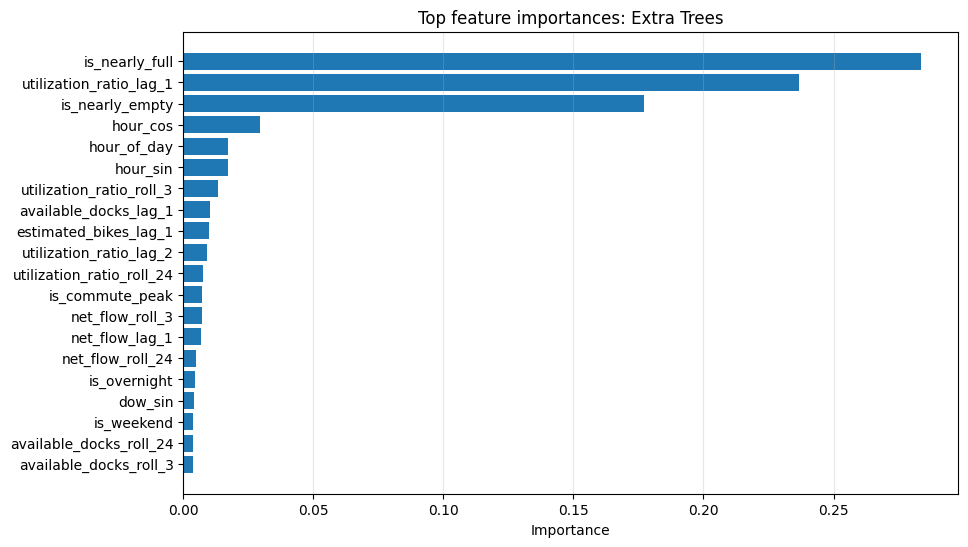

In [14]:

if 'best_model_family' not in globals():
    print('Run the model family sweep first.')
else:
    if best_model_family in model_sweep_artifacts:
        fi = top_feature_importance(model_sweep_artifacts, best_model_family, top_k=20)
    else:
        fi = None

    if fi is None:
        print('No tree-based feature importance available for the selected model.')
    else:
        display(fi)
        plot_df = fi.sort_values('importance')
        plt.figure(figsize=(10, 6))
        plt.barh(plot_df['feature'], plot_df['importance'])
        plt.title(f'Top feature importances: {best_model_family}')
        plt.xlabel('Importance')
        plt.grid(True, axis='x', alpha=0.3)
        plt.show()



## Optional: save result tables

This writes the main summaries to CSV so you can reuse them in the report.


In [15]:

output_dir = globals().get('OUTPUT_DIR')

if SAVE_OUTPUT_TABLES and output_dir is not None:
    saved = []

    objects_to_save = {
        'availability_improvement_baseline_metrics.csv': globals().get('baseline_metrics'),
        'availability_improvement_model_sweep_results.csv': globals().get('model_sweep_results'),
        'availability_improvement_feature_sweep_results.csv': globals().get('feature_sweep_results'),
        'availability_improvement_ensemble_metrics.csv': globals().get('ensemble_metrics'),
        'availability_improvement_ensemble_weights.csv': globals().get('ensemble_weights'),
        'availability_improvement_routing_results.csv': globals().get('routing_results'),
        'availability_improvement_candidate_summary.csv': globals().get('candidate_summary'),
        'availability_improvement_global_regime_breakdown.csv': globals().get('global_regime_breakdown'),
        'availability_improvement_routed_regime_breakdown.csv': globals().get('routed_regime_breakdown'),
    }

    for filename, obj in objects_to_save.items():
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            out_path = output_dir / filename
            obj.to_csv(out_path, index=False)
            saved.append(str(out_path))

    if saved:
        print('Saved files:')
        for p in saved:
            print(' -', p)
    else:
        print('No non-empty result tables were available to save yet.')
else:
    print('Saving skipped.')


Saved files:
 - outputs/availability_improvement_feature_sweep_results.csv
 - outputs/availability_improvement_ensemble_metrics.csv
 - outputs/availability_improvement_ensemble_weights.csv
 - outputs/availability_improvement_routing_results.csv
 - outputs/availability_improvement_candidate_summary.csv
 - outputs/availability_improvement_global_regime_breakdown.csv
 - outputs/availability_improvement_routed_regime_breakdown.csv



## How to talk about this notebook in the report

### What this notebook adds
The follow-on notebook showed that **availability-first modeling** was the right direction after v7. This notebook goes one step further and asks whether that availability target can be improved with stronger modeling choices.

### Good report storyline
- Start from the follow-on conclusion that `utilization_ratio_next_hour` is the strongest target.
- State that the strongest follow-on setting was used as the base configuration.
- Compare stronger model families and say whether they beat the original random-forest baseline.
- Show whether engineered availability-pressure features helped.
- If the routed model helps, explain that **station behavior depends on current occupancy regime**, so a single global model is not always the best approximation.
- Use the regime breakdown table to discuss whether errors are concentrated near the operational edges.

### If the strongest model does not improve much
That is still useful. It means v7 already captured most of the easy signal, and the project can pivot toward:
- alert classification,
- operational decision rules,
- or better external features rather than endlessly tuning regressors.
